In [44]:
%load_ext autoreload
%load_ext line_profiler
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [45]:
import pandas as pd
from krxns.network import ReactionNetwork
from ergochemics.draw import draw_reaction
from IPython.display import SVG

In [46]:
G = ReactionNetwork.from_json('/home/stef/krxns/data/processed/known_reaction_network.json')
print("Full reaction network loaded from JSON.")
print(f"Number of nodes: {G.number_of_nodes()}, Number of edges: {G.number_of_edges()}")
default_sources = pd.read_csv('/home/stef/krxns/data/interim/default_sources.csv')['smiles'].tolist()


Full reaction network loaded from JSON.
Number of nodes: 9253, Number of edges: 87418


In [47]:
kcs = pd.read_parquet('/home/stef/krxns/data/raw/known_compounds.parquet')
krs = pd.read_parquet('/home/stef/krxns/data/raw/mapped_known_reactions_x_rc_plus_0_rules.parquet')
kcs.head()

,id,smiles,name,chebi_id,n_atoms
0,0,*,A,CHEBI:13193,1
1,1,**,RX,CHEBI:17792,2
2,2,*C,an alkane,CHEBI:18310,2
3,3,*C#N,a nitrile,CHEBI:18379,3
4,4,*C(*)(O)C(*)(*)O,an ethanediol,CHEBI:140594,8


In [48]:
kcs[kcs['name'].str.contains('2-ethyl-2-hydroxy-3-oxobutanoate')]

,id,smiles,name,chebi_id,n_atoms
4208,4208,CCC(O)(C(C)=O)C(=O)O,(S)-2-ethyl-2-hydroxy-3-oxobutanoate,CHEBI:49256,10


In [49]:
addtl_sources = {
    'lactate': 'CC(O)C(=O)O',
    'threonine': 'CC(O)C(N)C(=O)O'
}

targets = {'2-ethyl-2-hydroxy-3-oxobutanoate': 'CCC(O)(C(C)=O)C(=O)O'}

In [50]:
sources = default_sources + list(addtl_sources.values())
G.set_sources(smiles=sources)
rnmc_lb = 0.25
pnmc_lb = 0.25
aug_mc_lb = 0.8
# G.prune(pnmc_lb=pnmc_lb, rnmc_lb=rnmc_lb, source_augmented_pnmc_lb=aug_mc_lb)

In [51]:
print(f"Pruned network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Pruned network: 9253 nodes, 87418 edges


In [52]:
G.get_nodes_by_prop('smiles', targets['2-ethyl-2-hydroxy-3-oxobutanoate'])

[1844]

In [53]:
%lprun -f G.enumerate_synthetic_trees G.enumerate_synthetic_trees(target=1844, max_depth=2, max_leaves=3, tot_rnmc_lb=0.1)

Timer unit: 1e-09 s

Total time: 174.365 s
File: /home/stef/krxns/src/krxns/network.py
Function: ReactionNetwork.enumerate_synthetic_trees at line 307

Line #      Hits         Time  Per Hit   % Time  Line Contents
   307                                                   '''
   308                                                   Enumerates synthetic trees for a given target compound in a reaction network.
   309                                           
   310                                                   Args
   311                                                   ----
   312                                                   target: int
   313                                                       Node index of the target compound for which to enumerate synthetic trees.
   314                                                   max_depth: int
   315                                                       Maximum depth of the synthetic tree.
   316                                   

In [83]:
trees = G.enumerate_synthetic_trees(target=1844, max_depth=3, max_leaves=3, tot_rnmc_lb=0.1)
print(f"Found {len(trees)} synthetic trees.")

Found 5 synthetic trees.


In [87]:
for i, tree in enumerate(trees):
    print(f"Tree {i}:")
    for leaf in tree.leaves:
        print(leaf[0], G.nodes[leaf[0]]['name'])
    print("\n")

Tree 0:
835 (R)-lactate
3281 O2
1423 D-threonine


Tree 1:
118 CO2
1423 D-threonine
835 (R)-lactate


Tree 2:
118 CO2
1423 D-threonine
1423 D-threonine


Tree 3:
6 NADP(+)
835 (R)-lactate
1423 D-threonine


Tree 4:
122 NAD(+)
835 (R)-lactate
1423 D-threonine




In [85]:
trees

[SyntheticTree(root=1844, generations=[{1844: '6642'}, {559: '12656', 1845: '12703'}, {835: None, 3281: None, 1423: None}], leaves=[(835, 2), (3281, 2), (1423, 2)]),
 SyntheticTree(root=1844, generations=[{1844: '6642'}, {559: '14354', 1845: '12703'}, {1842: '12667', 118: None, 1423: None}, {835: None}], leaves=[(118, 2), (1423, 2), (835, 3)]),
 SyntheticTree(root=1844, generations=[{1844: '6642'}, {559: '14354', 1845: '12703'}, {1842: '12702', 118: None, 1423: None}, {1423: None}], leaves=[(118, 2), (1423, 2), (1423, 3)]),
 SyntheticTree(root=1844, generations=[{1844: '6642'}, {559: '12643', 1845: '12703'}, {6: None, 835: None, 1423: None}], leaves=[(6, 2), (835, 2), (1423, 2)]),
 SyntheticTree(root=1844, generations=[{1844: '6642'}, {559: '12642', 1845: '12703'}, {122: None, 835: None, 1423: None}], leaves=[(122, 2), (835, 2), (1423, 2)])]

Tree 0:
  Generation 0:


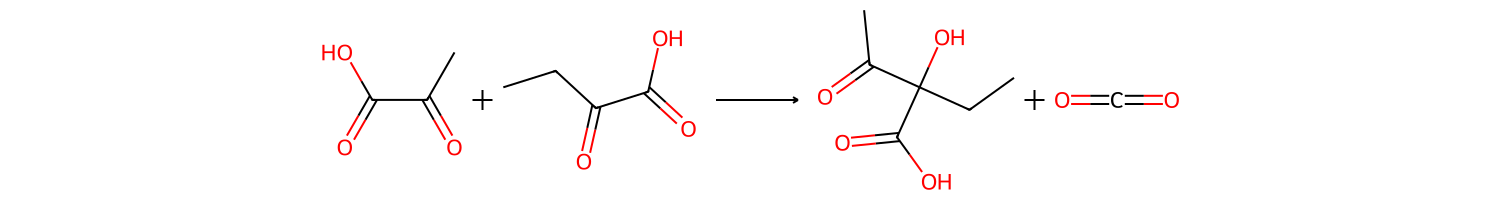

  Generation 1:


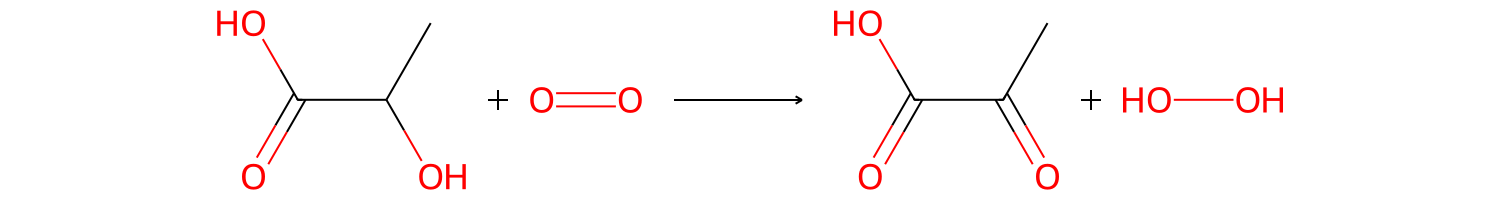

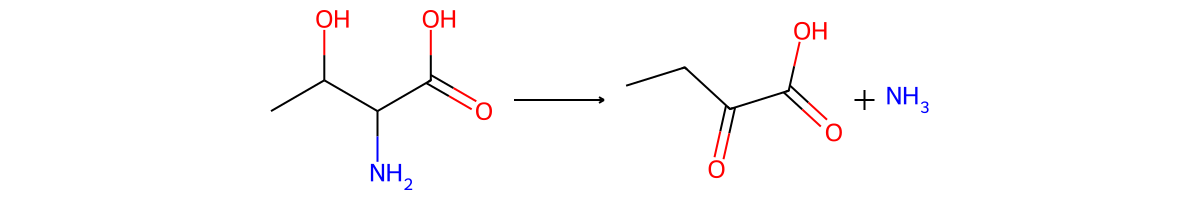

  Generation 2:
Tree 1:
  Generation 0:


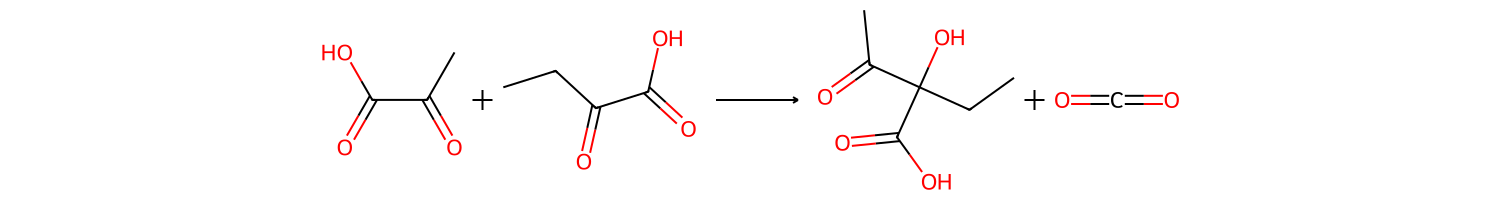

  Generation 1:


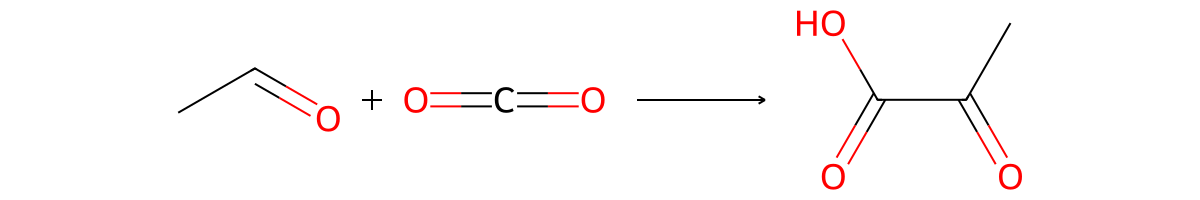

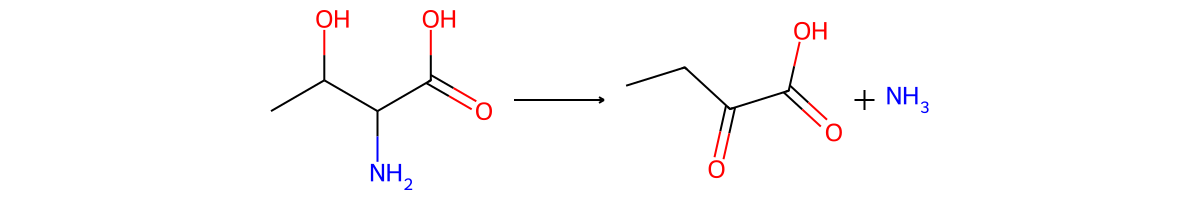

  Generation 2:


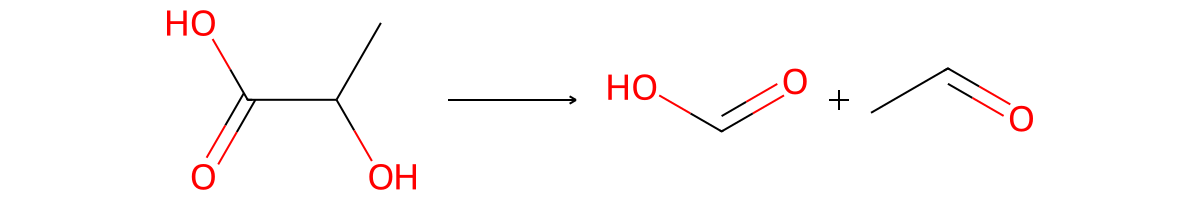

  Generation 3:
Tree 2:
  Generation 0:


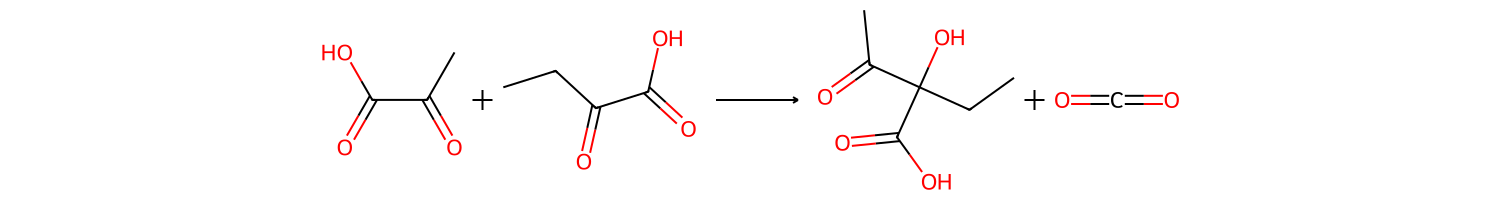

  Generation 1:


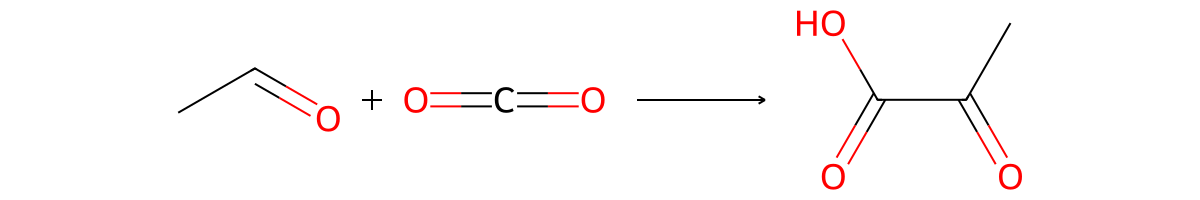

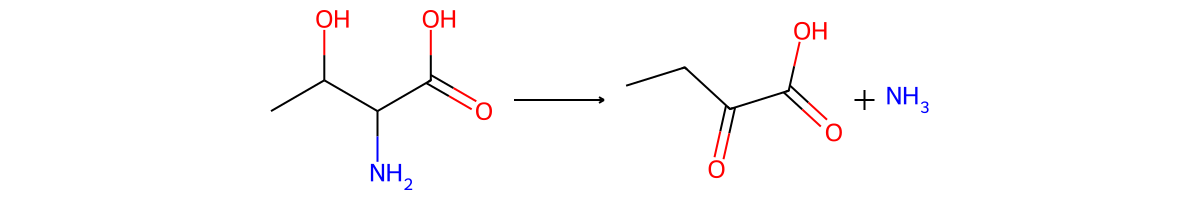

  Generation 2:


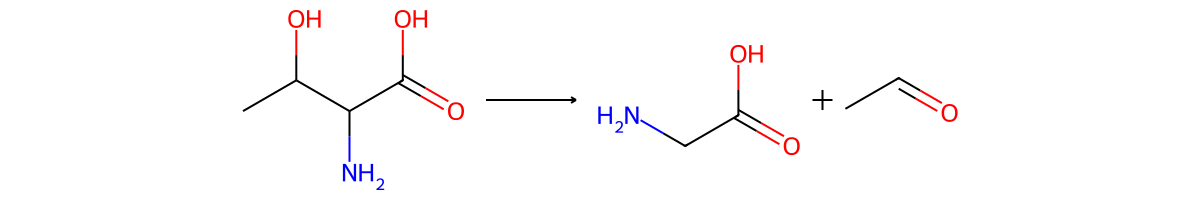

  Generation 3:
Tree 3:
  Generation 0:


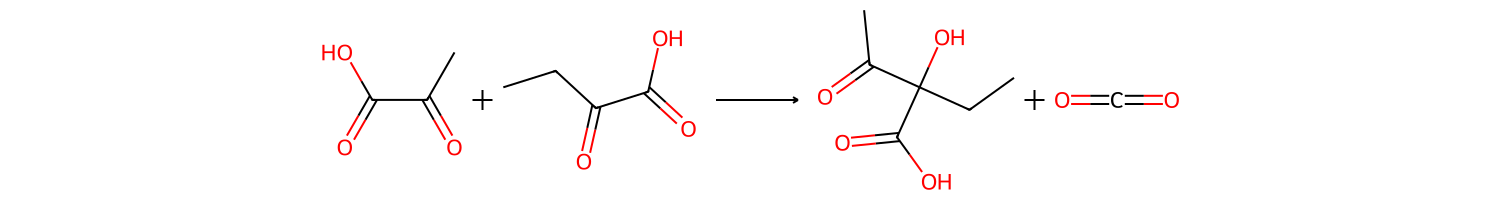

  Generation 1:


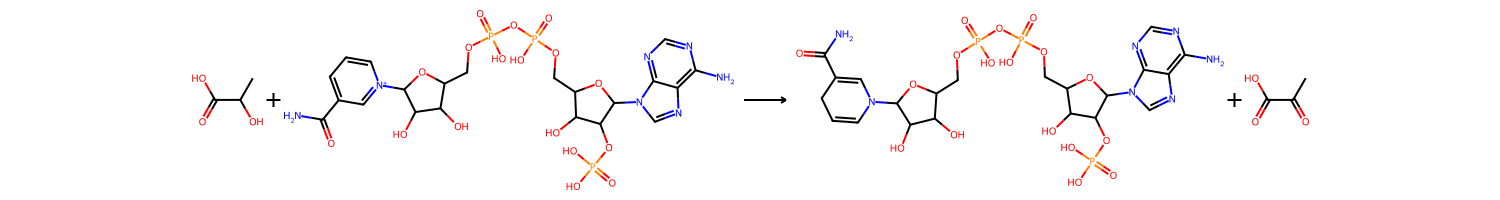

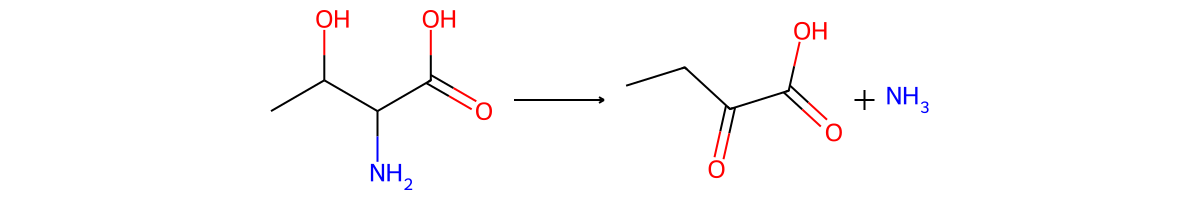

  Generation 2:
Tree 4:
  Generation 0:


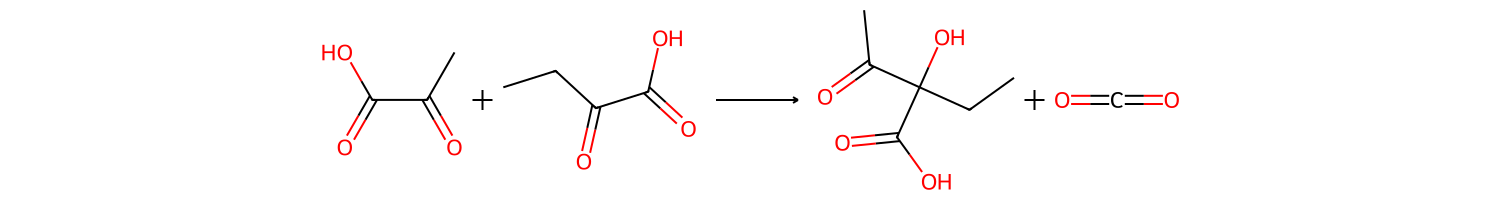

  Generation 1:


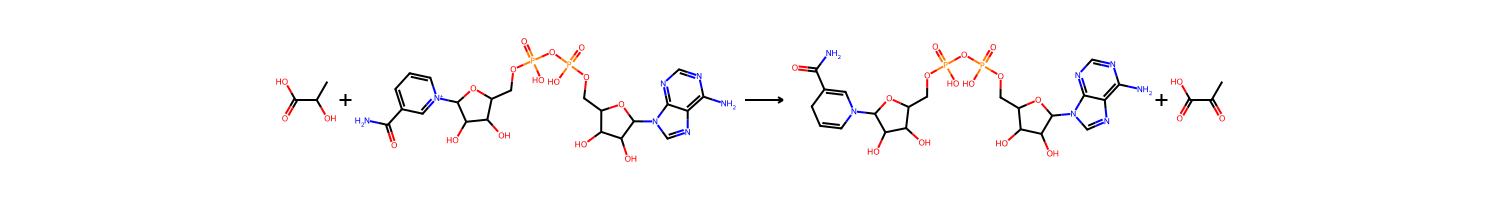

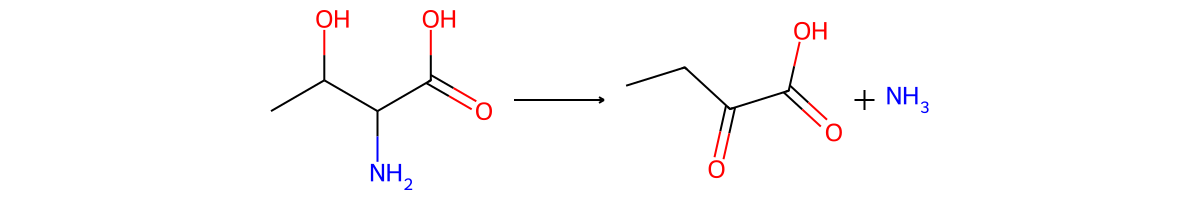

  Generation 2:


In [86]:
for i, tree in enumerate(trees):
    print(f"Tree {i}:")
    for j, gen in enumerate(tree.generations):
        print(f"  Generation {j}:")
        for rid in gen.values():
            if rid is not None:
                rid = int(rid)
            else:
                continue
            rxn = krs.loc[krs['rxn_id'] == rid, 'smarts'].values[0]
            display(SVG(draw_reaction(rxn)))

In [58]:
from copy import deepcopy, copy

In [59]:
foo = [(1,2), (3,4)]
bar = copy(foo)
bar[0] = (5,6)
foo, bar

([(1, 2), (3, 4)], [(5, 6), (3, 4)])

In [60]:
foo = [(1,2), (3,4)]
bar = deepcopy(foo)
bar[0] = (5,6)
foo, bar

([(1, 2), (3, 4)], [(5, 6), (3, 4)])

In [61]:
foo = [{1:2}, {3:4}]
bar = deepcopy(foo)
bar[0][1] = 5
foo, bar

([{1: 2}, {3: 4}], [{1: 5}, {3: 4}])

In [62]:
foo = [{1:2}, {3:4}]
bar = copy(foo)
bar[0][1] = 5
foo, bar

([{1: 5}, {3: 4}], [{1: 5}, {3: 4}])

In [63]:
def times_1000(f):
    def wrapper(*args, **kwargs):
        result = f(*args, **kwargs)
        return result * 1000
    return wrapper

In [64]:
@times_1000
def deep_copy(arg: list[dict]) -> list[dict]:
    """
    Deep copy a list of dictionaries.
    """
    return [deepcopy(item) for item in arg]

In [65]:
@times_1000
def shallow_copy(arg: list[dict]) -> list[dict]:
    """
    Shallow copy a list of dictionaries.
    """
    return [copy(item) for item in arg]

In [66]:
@times_1000
def recomprehension(arg: list[dict]) -> list[dict]:
    """
    Re-comprehension of a list of dictionaries.
    """
    return [item for item in arg]

In [67]:
%timeit deep_copy([{'a': 1}, {'b': 2}])

5.56 μs ± 69.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [68]:
%timeit shallow_copy([{'a': 1}, {'b': 2}])

2.58 μs ± 44.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [69]:
%timeit recomprehension([{'a': 1}, {'b': 2}])

2.27 μs ± 40.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
